# Appendix

Compact notebook for the paper appendix tables and plots. The notebook uses existing benchmark outputs under `results/` by default. Expensive diagnostic recomputation is guarded by explicit flags and kept off by default.


In [1]:
from __future__ import annotations

from pathlib import Path
import math
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
RESULTS_DIR = ROOT / 'results'
OUTPUT_DIR = ROOT / 'notebooks' / 'generated'

for path in (ROOT, ROOT / 'src'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25})

RECOMPUTE_ROBUSTNESS = False
RECOMPUTE_SHRINKAGE = False
RECOMPUTE_LIRPA = False
EXPORT_OUTPUTS = False

DATASET_ORDER = [
    'adult',
    'compas',
    'german_credit',
    'give_me_some_credit',
    'heloc',
    'lending_club',
    'wisconsin_breast_cancer',
]

PAPER_CERTCF_ALPHA = 0.20
PAPER_CERTCF_LAMBDA = 1.0
PAPER_CERTCF_LABEL = f'CertCF a={PAPER_CERTCF_ALPHA:.2f} lam={PAPER_CERTCF_LAMBDA:g}'
METHOD_ORDER = [PAPER_CERTCF_LABEL, 'NN10000', 'Growing Spheres', 'DiCE', 'FACE']
PALETTE = {
    PAPER_CERTCF_LABEL: '#087F5B',
    'NN10000': '#1864AB',
    'Growing Spheres': '#F08C00',
    'DiCE': '#C92A2A',
    'FACE': '#7048E8',
}


## Load Paper Benchmark Results

This mirrors the paper run selection: CertCF is taken from the shrink+sparsity sweep, FACE from the FACE run, and the remaining baselines from the no-FACE run.


In [2]:
CERTCF_SWEEP_RE = re.compile(r'eps_alpha=([0-9.]+)-sparsity_lambda=([0-9.]+)')
CERTCF_OLD_RE = re.compile(r'eps_alpha=([0-9.]+)')


def parse_certcf_hparams(run_name: object) -> tuple[float, float]:
    text = str(run_name)
    match = CERTCF_SWEEP_RE.search(text)
    if match:
        return float(match.group(1)), float(match.group(2))
    match = CERTCF_OLD_RE.search(text)
    if match:
        return float(match.group(1)), np.nan
    return np.nan, np.nan


def method_label(row: pd.Series) -> str:
    method = str(row['method'])
    run_name = str(row.get('run_name', method))
    if method == 'certcf':
        alpha, lam = parse_certcf_hparams(run_name)
        if np.isfinite(alpha) and np.isfinite(lam):
            return f'CertCF a={alpha:.2f} lam={lam:g}'
        if np.isfinite(alpha):
            return f'CertCF old a={alpha:.2f}'
        return run_name
    if method == 'nearest_neighbor':
        return 'NN10000'
    if method == 'growing_spheres':
        return 'Growing Spheres'
    if method == 'dice':
        return 'DiCE'
    if method == 'face':
        return 'FACE'
    return run_name


RESULT_FILE_SPECS = [
    {
        'result_key': 'final_benchmark_noface',
        'path': RESULTS_DIR / 'final_benchmark_noface.parquet',
        'excluded_methods': {'face', 'certcf'},
        'included_run_names_by_method': {'growing_spheres': {'gs_max_radius=50.0'}},
    },
    {
        'result_key': 'final_benchmark_noface_certcf_shrink_sparsity',
        'path': RESULTS_DIR / 'final_benchmark_noface_certcf_shrink_sparsity.parquet',
        'included_methods': {'certcf'},
    },
    {
        'result_key': 'final_benchmark_face',
        'path': RESULTS_DIR / 'final_benchmark_face.parquet',
        'included_methods': {'face'},
    },
]

status_df = pd.DataFrame([
    {
        'result_key': spec['result_key'],
        'path': str(spec['path'].relative_to(ROOT) if spec['path'].is_relative_to(ROOT) else spec['path']),
        'available': spec['path'].exists(),
        'size_mb': spec['path'].stat().st_size / 1024**2 if spec['path'].exists() else np.nan,
    }
    for spec in RESULT_FILE_SPECS
])
display(status_df)

missing = status_df.loc[~status_df['available'], 'path'].tolist()
if missing:
    raise FileNotFoundError('Missing result files:\n' + '\n'.join(missing))

frames = []
for spec in RESULT_FILE_SPECS:
    frame = pd.read_parquet(spec['path']).copy()
    if spec.get('included_methods') is not None:
        frame = frame[frame['method'].astype(str).isin(spec['included_methods'])].copy()
    if spec.get('excluded_methods'):
        frame = frame[~frame['method'].astype(str).isin(spec['excluded_methods'])].copy()
    for method_name, run_names in spec.get('included_run_names_by_method', {}).items():
        mask = frame['method'].astype(str).eq(method_name)
        frame = frame[~mask | frame['run_name'].astype(str).isin(run_names)].copy()
    if 'run_name' not in frame.columns:
        frame['run_name'] = frame['method'].astype(str)
    frame['result_key'] = spec['result_key']
    frames.append(frame)

RAW_BENCHMARK_DF = pd.concat(frames, ignore_index=True)
RAW_BENCHMARK_DF['method_label'] = RAW_BENCHMARK_DF.apply(method_label, axis=1)
PAPER_DF = RAW_BENCHMARK_DF[RAW_BENCHMARK_DF['method_label'].astype(str).isin(METHOD_ORDER)].copy()
PAPER_DF['dataset'] = pd.Categorical(PAPER_DF['dataset'].astype(str), DATASET_ORDER, ordered=True)
PAPER_DF['method_label'] = pd.Categorical(PAPER_DF['method_label'].astype(str), METHOD_ORDER, ordered=True)
PAPER_DF = PAPER_DF.sort_values(['dataset', 'method_label', 'query_idx'], ignore_index=True)

print({'rows': len(PAPER_DF), 'datasets': PAPER_DF['dataset'].nunique(), 'methods': PAPER_DF['method_label'].nunique()})
display(PAPER_DF.groupby(['dataset', 'method_label'], observed=True)['success'].agg(['count', 'mean']).head(15))


,result_key,path,available,size_mb
0,final_benchmark_noface,results/final_benchmark_noface.parquet,True,4.375778
1,final_benchmark_noface_certcf_shrink_sparsity,results/final_benchmark_noface_certcf_shrink_s...,True,33.904958
2,final_benchmark_face,results/final_benchmark_face.parquet,True,0.917765


{'rows': 23865, 'datasets': 7, 'methods': 5}


/tmp/ipykernel_91690/2719612604.py:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  RAW_BENCHMARK_DF['method_label'] = RAW_BENCHMARK_DF.apply(method_label, axis=1)


count      mean
dataset       method_label                        
adult         CertCF a=0.20 lam=1   1000  1.000000
              NN10000               1000  1.000000
              Growing Spheres       1000  0.991000
              DiCE                  1000  0.902000
              FACE                  1000  0.990000
compas        CertCF a=0.20 lam=1    617  1.000000
              NN10000                617  1.000000
              Growing Spheres        617  1.000000
              DiCE                   617  0.842788
              FACE                   617  0.995138
german_credit CertCF a=0.20 lam=1    100  1.000000
              NN10000                100  1.000000
              Growing Spheres        100  1.000000
              DiCE                   100  0.880000
              FACE                   100  0.970000

## Hyperparameter Configuration

Main benchmark hyperparameters and the FACE graph-radius values reported in the appendix.


In [3]:
HYPERPARAMETER_DF = pd.DataFrame([
    ('CertCF', 'alpha', '0.20'),
    ('CertCF', 'sparsity_lambda', '1.0'),
    ('DiCE', 'diversity_weight', '0.0'),
    ('DiCE', 'proximity_weight', '1.0'),
    ('DiCE', 'min_iter', '50'),
    ('FACE', 'tp', '0.5'),
    ('FACE', 'epsilon', 'dataset-specific'),
    ('Growing Spheres', 'max_radius', '50.0'),
    ('Growing Spheres', 'radius_step', '0.25'),
    ('Growing Spheres', 'n_samples_in_layer', '1000'),
], columns=['method', 'hyperparameter', 'value'])

FACE_EPSILON_DF = pd.DataFrame([
    ('adult', 2.9),
    ('compas', 1.5),
    ('german_credit', 3.6),
    ('give_me_some_credit', 1.1),
    ('heloc', 3.3),
    ('lending_club', 2.6),
    ('wisconsin_breast_cancer', 4.5),
], columns=['dataset', 'face_epsilon'])

print('Main hyperparameters')
display(HYPERPARAMETER_DF)
print('FACE graph radius values')
display(FACE_EPSILON_DF)


Main hyperparameters


,method,hyperparameter,value
0,CertCF,alpha,0.20
1,CertCF,sparsity_lambda,1.0
2,DiCE,diversity_weight,0.0
3,DiCE,proximity_weight,1.0
4,DiCE,min_iter,50
5,FACE,tp,0.5
6,FACE,epsilon,dataset-specific
7,Growing Spheres,max_radius,50.0
8,Growing Spheres,radius_step,0.25
9,Growing Spheres,n_samples_in_layer,1000


FACE graph radius values


,dataset,face_epsilon
0,adult,2.9
1,compas,1.5
2,german_credit,3.6
3,give_me_some_credit,1.1
4,heloc,3.3
5,lending_club,2.6
6,wisconsin_breast_cancer,4.5


## Robustness Heatmaps

The default cell below uses the paper heatmap values produced by the main benchmark notebook. Keep `RECOMPUTE_ROBUSTNESS=False` unless you explicitly want to reload all classifiers and re-run the perturbation grid.


,method,categorical_flip_p,numerical_sigma,target_robustness_pct
0,CertCF,0.0,0.00,100.0
1,CertCF,0.0,0.01,99.0
2,CertCF,0.0,0.03,98.0
3,CertCF,0.0,0.05,96.0
4,CertCF,0.0,0.10,92.0


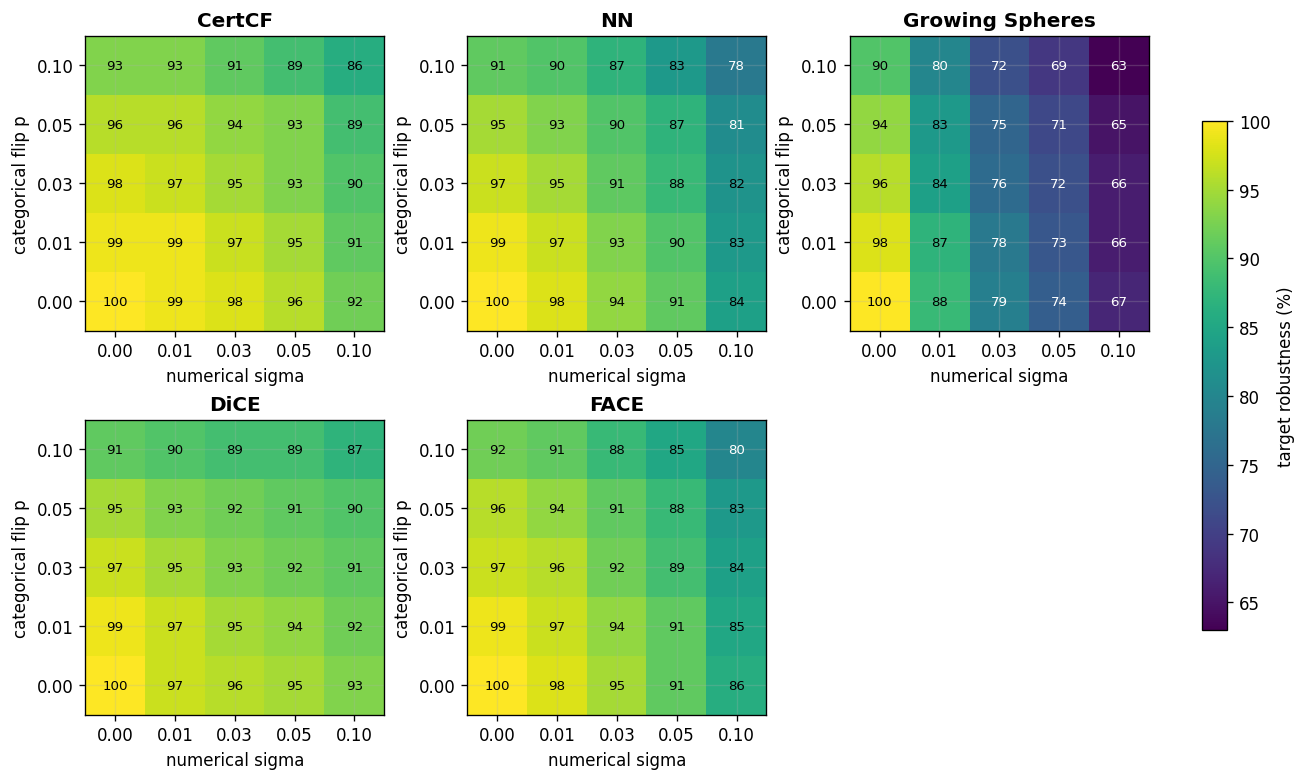

In [4]:
ROBUSTNESS_SIGMA_GRID = [0.00, 0.01, 0.03, 0.05, 0.10]
ROBUSTNESS_CAT_FLIP_GRID = [0.00, 0.01, 0.03, 0.05, 0.10]
ROBUSTNESS_VALUES = {
    'CertCF': [
        [100, 99, 98, 96, 92],
        [99, 99, 97, 95, 91],
        [98, 97, 95, 93, 90],
        [96, 96, 94, 93, 89],
        [93, 93, 91, 89, 86],
    ],
    'NN': [
        [100, 98, 94, 91, 84],
        [99, 97, 93, 90, 83],
        [97, 95, 91, 88, 82],
        [95, 93, 90, 87, 81],
        [91, 90, 87, 83, 78],
    ],
    'Growing Spheres': [
        [100, 88, 79, 74, 67],
        [98, 87, 78, 73, 66],
        [96, 84, 76, 72, 66],
        [94, 83, 75, 71, 65],
        [90, 80, 72, 69, 63],
    ],
    'DiCE': [
        [100, 97, 96, 95, 93],
        [99, 97, 95, 94, 92],
        [97, 95, 93, 92, 91],
        [95, 93, 92, 91, 90],
        [91, 90, 89, 89, 87],
    ],
    'FACE': [
        [100, 98, 95, 91, 86],
        [99, 97, 94, 91, 85],
        [97, 96, 92, 89, 84],
        [96, 94, 91, 88, 83],
        [92, 91, 88, 85, 80],
    ],
}


def robustness_values_to_df(values: dict[str, list[list[float]]]) -> pd.DataFrame:
    rows = []
    for method, grid in values.items():
        arr = np.asarray(grid, dtype=float)
        for row_idx, flip_p in enumerate(ROBUSTNESS_CAT_FLIP_GRID):
            for col_idx, sigma in enumerate(ROBUSTNESS_SIGMA_GRID):
                rows.append({
                    'method': method,
                    'categorical_flip_p': flip_p,
                    'numerical_sigma': sigma,
                    'target_robustness_pct': arr[row_idx, col_idx],
                })
    return pd.DataFrame(rows)


ROBUSTNESS_HEATMAP_DF = robustness_values_to_df(ROBUSTNESS_VALUES)
display(ROBUSTNESS_HEATMAP_DF.head())


def plot_robustness_heatmaps(grid_df: pd.DataFrame):
    methods = ['CertCF', 'NN', 'Growing Spheres', 'DiCE', 'FACE']
    fig, axes = plt.subplots(2, 3, figsize=(10.8, 6.4), constrained_layout=True)
    axes = axes.ravel()
    vmin, vmax = grid_df['target_robustness_pct'].min(), grid_df['target_robustness_pct'].max()
    for ax, method in zip(axes, methods):
        heat = (
            grid_df[grid_df['method'].eq(method)]
            .pivot(index='categorical_flip_p', columns='numerical_sigma', values='target_robustness_pct')
            .reindex(index=ROBUSTNESS_CAT_FLIP_GRID, columns=ROBUSTNESS_SIGMA_GRID)
        )
        image = ax.imshow(heat.to_numpy(), origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_title(method, fontweight='bold')
        ax.set_xticks(range(len(ROBUSTNESS_SIGMA_GRID)), [f'{v:.2f}' for v in ROBUSTNESS_SIGMA_GRID])
        ax.set_yticks(range(len(ROBUSTNESS_CAT_FLIP_GRID)), [f'{v:.2f}' for v in ROBUSTNESS_CAT_FLIP_GRID])
        ax.set_xlabel('numerical sigma')
        ax.set_ylabel('categorical flip p')
        for row_idx in range(heat.shape[0]):
            for col_idx in range(heat.shape[1]):
                value = heat.iloc[row_idx, col_idx]
                ax.text(col_idx, row_idx, f'{value:.0f}', ha='center', va='center', fontsize=8, color='white' if value < 82 else 'black')
    axes[-1].axis('off')
    fig.colorbar(image, ax=axes.tolist(), shrink=0.75, label='target robustness (%)')
    return fig, axes

plot_robustness_heatmaps(ROBUSTNESS_HEATMAP_DF);


## Computational Complexity

Offline build-time summaries are meaningful for CertCF and FACE. Query-time summaries include all methods; DiCE uses the dedicated batch-size-one run when available.


In [5]:
def summarize_build_times(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for method_label in [PAPER_CERTCF_LABEL, 'FACE']:
        values = []
        for _, group in df[df['method_label'].astype(str).eq(method_label)].groupby('dataset', observed=True):
            build = pd.to_numeric(group['build_time_s'], errors='coerce').dropna().to_numpy(dtype=float)
            if len(build):
                values.append(float(build[0]))
        if values:
            arr = np.asarray(values, dtype=float)
            rows.append({
                'method': 'CertCF' if method_label == PAPER_CERTCF_LABEL else method_label,
                'mean_s': arr.mean(),
                'median_s': np.median(arr),
                'min_s': arr.min(),
                'max_s': arr.max(),
            })
    return pd.DataFrame(rows)


def summarize_query_times(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    query_df = df.copy()
    dice_batch1 = RESULTS_DIR / 'dice_query_batch1_20queries.parquet'
    if dice_batch1.exists():
        dice_df = pd.read_parquet(dice_batch1).copy()
        dice_df['method_label'] = 'DiCE'
        query_df = query_df[~query_df['method_label'].astype(str).eq('DiCE')].copy()
        query_df = pd.concat([query_df, dice_df], ignore_index=True, sort=False)
    label_map = {PAPER_CERTCF_LABEL: 'CertCF', 'NN10000': 'NN'}
    for method_label in METHOD_ORDER:
        label = label_map.get(method_label, method_label)
        values = []
        for _, group in query_df[query_df['method_label'].astype(str).eq(method_label)].groupby('dataset', observed=True):
            runtime = pd.to_numeric(group['runtime_s'], errors='coerce').dropna().to_numpy(dtype=float)
            if len(runtime):
                values.append(float(np.mean(runtime)))
        if values:
            arr = np.asarray(values, dtype=float)
            rows.append({
                'method': label,
                'mean_s': arr.mean(),
                'median_s': np.median(arr),
                'min_s': arr.min(),
                'max_s': arr.max(),
            })
    return pd.DataFrame(rows)


BUILD_TIME_DF = summarize_build_times(PAPER_DF)
QUERY_TIME_DF = summarize_query_times(PAPER_DF)
print('Offline build time')
display(BUILD_TIME_DF.round(4))
print('Online query time')
display(QUERY_TIME_DF.round(4))


Offline build time


,method,mean_s,median_s,min_s,max_s
0,CertCF,22.2594,25.1262,7.8688,33.6739
1,FACE,3080.3492,1350.4049,16.4792,14249.9245


Online query time


,method,mean_s,median_s,min_s,max_s
0,CertCF,0.4296,0.2075,0.0889,1.7432
1,NN,0.0003,0.0002,0.0000,0.0012
2,Growing Spheres,0.0280,0.0115,0.0011,0.0783
3,DiCE,1.6300,1.6283,0.8337,2.6999
4,FACE,2.4032,1.6111,0.0063,7.6172


## Shrinkage Ablation

Set `RECOMPUTE_SHRINKAGE=True` to rebuild the HELOC shrinkage diagnostics from scratch. By default this section only documents the paper-facing computation and avoids a long LiRPA run.


In [6]:
if RECOMPUTE_SHRINKAGE:
    raise NotImplementedError(
        'The full shrinkage recomputation is preserved in notebooks/archive/6.35 - CertCF shrinkage ablation HELOC.ipynb. '
        'Run that archived notebook if the HELOC diagnostic data must be regenerated.'
    )

SHRINKAGE_DESCRIPTION_DF = pd.DataFrame([
    {
        'diagnostic': 'HELOC final epsilon distribution',
        'source_notebook': 'notebooks/archive/6.35 - CertCF shrinkage ablation HELOC.ipynb',
        'default_behavior': 'not recomputed',
        'paper_interpretation': 'adaptive shrinkage keeps final certified radii stable as alpha grows',
    }
])
display(SHRINKAGE_DESCRIPTION_DF)


,diagnostic,source_notebook,default_behavior,paper_interpretation
0,HELOC final epsilon distribution,notebooks/archive/6.35 - CertCF shrinkage abla...,not recomputed,adaptive shrinkage keeps final certified radii...


## Alpha And Lambda Ablations

These plots are computed from the CertCF shrink+sparsity sweep and the lambda-zero run.


In [7]:
SPARSE_RESULT_PATH = RESULTS_DIR / 'final_benchmark_noface_certcf_shrink_sparsity.parquet'
LAMBDA_ZERO_RESULT_PATH = RESULTS_DIR / 'final_benchmark_noface_certcf_shrink_sparsity_lambda0.parquet'
SPARSE_RUN_RE = re.compile(r'eps_alpha=([0-9.]+)-sparsity_lambda=([0-9.]+)')
ALPHA_RE = re.compile(r'eps_alpha=([0-9.]+)')
SELECTED_ALPHA = 0.20


def parse_sparse_hparams(run_name: object) -> tuple[float, float]:
    text = str(run_name)
    match = SPARSE_RUN_RE.search(text)
    if match:
        return float(match.group(1)), float(match.group(2))
    match = ALPHA_RE.search(text)
    if match:
        return float(match.group(1)), 0.0
    return np.nan, np.nan


def feature_columns(df: pd.DataFrame, prefix: str) -> list[str]:
    cols = [col for col in df.columns if col.startswith(prefix)]
    return sorted(cols, key=lambda col: int(col.rsplit('_', 1)[-1]))


def add_l0_count(df: pd.DataFrame, tol: float = 1.0e-6) -> pd.DataFrame:
    out = df.copy()
    out['l0_count'] = np.nan
    for dataset, group in out.groupby('dataset', observed=True):
        x_cols = feature_columns(group, 'x_orig_')
        cf_cols = feature_columns(group, 'x_cf_')
        if not x_cols or not cf_cols:
            continue
        idx = group.index
        diff = np.abs(out.loc[idx, cf_cols].to_numpy(dtype=float) - out.loc[idx, x_cols].to_numpy(dtype=float))
        out.loc[idx, 'l0_count'] = (diff > tol).sum(axis=1)
    return out


def load_sparse_sweep() -> pd.DataFrame:
    frames = []
    for path in [LAMBDA_ZERO_RESULT_PATH, SPARSE_RESULT_PATH]:
        if path.exists():
            frame = pd.read_parquet(path).copy()
            frame = frame[frame['method'].astype(str).eq('certcf')].copy()
            parsed = frame['run_name'].map(parse_sparse_hparams)
            frame['alpha'] = [p[0] for p in parsed]
            frame['sparsity_lambda'] = [p[1] for p in parsed]
            frames.append(frame)
    if not frames:
        raise FileNotFoundError('Missing CertCF sparsity sweep parquet files.')
    df = pd.concat(frames, ignore_index=True, sort=False)
    df['success_bool'] = df['success'].fillna(False).astype(bool)
    return add_l0_count(df)


def summarize_sparse_sweep(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, alpha, lam), group in df.groupby(['dataset', 'alpha', 'sparsity_lambda'], observed=True):
        ok = group[group['success_bool']]
        rows.append({
            'dataset': dataset,
            'alpha': alpha,
            'sparsity_lambda': lam,
            'validity_pct': 100.0 * group['success_bool'].mean(),
            'l1_mean': ok['l1_distance'].mean(),
            'l0_mean': ok['l0_count'].mean(),
        })
    by_dataset = pd.DataFrame(rows)
    return (
        by_dataset
        .groupby(['alpha', 'sparsity_lambda'], observed=True)
        .agg(validity_pct=('validity_pct', 'mean'), l1_mean=('l1_mean', 'mean'), l0_mean=('l0_mean', 'mean'))
        .reset_index()
        .sort_values(['alpha', 'sparsity_lambda'], ignore_index=True)
    )


CERTCF_SWEEP_DF = load_sparse_sweep()
CERTCF_ABLATION_DF = summarize_sparse_sweep(CERTCF_SWEEP_DF)
display(CERTCF_ABLATION_DF.round(4))


,alpha,sparsity_lambda,validity_pct,l1_mean,l0_mean
0,0.10,0.0,100.0,7.6424,11.4592
1,0.10,0.1,100.0,7.5475,9.0780
2,0.10,0.2,100.0,7.5674,8.9293
3,0.10,0.5,100.0,7.6608,8.6743
4,0.10,1.0,100.0,7.7385,8.5555
5,0.15,0.0,100.0,7.5627,11.4540
6,0.15,0.1,100.0,7.4668,8.7170
7,0.15,0.2,100.0,7.4874,8.5807
8,0.15,0.5,100.0,7.5792,8.3030
9,0.15,1.0,100.0,7.6592,8.1924


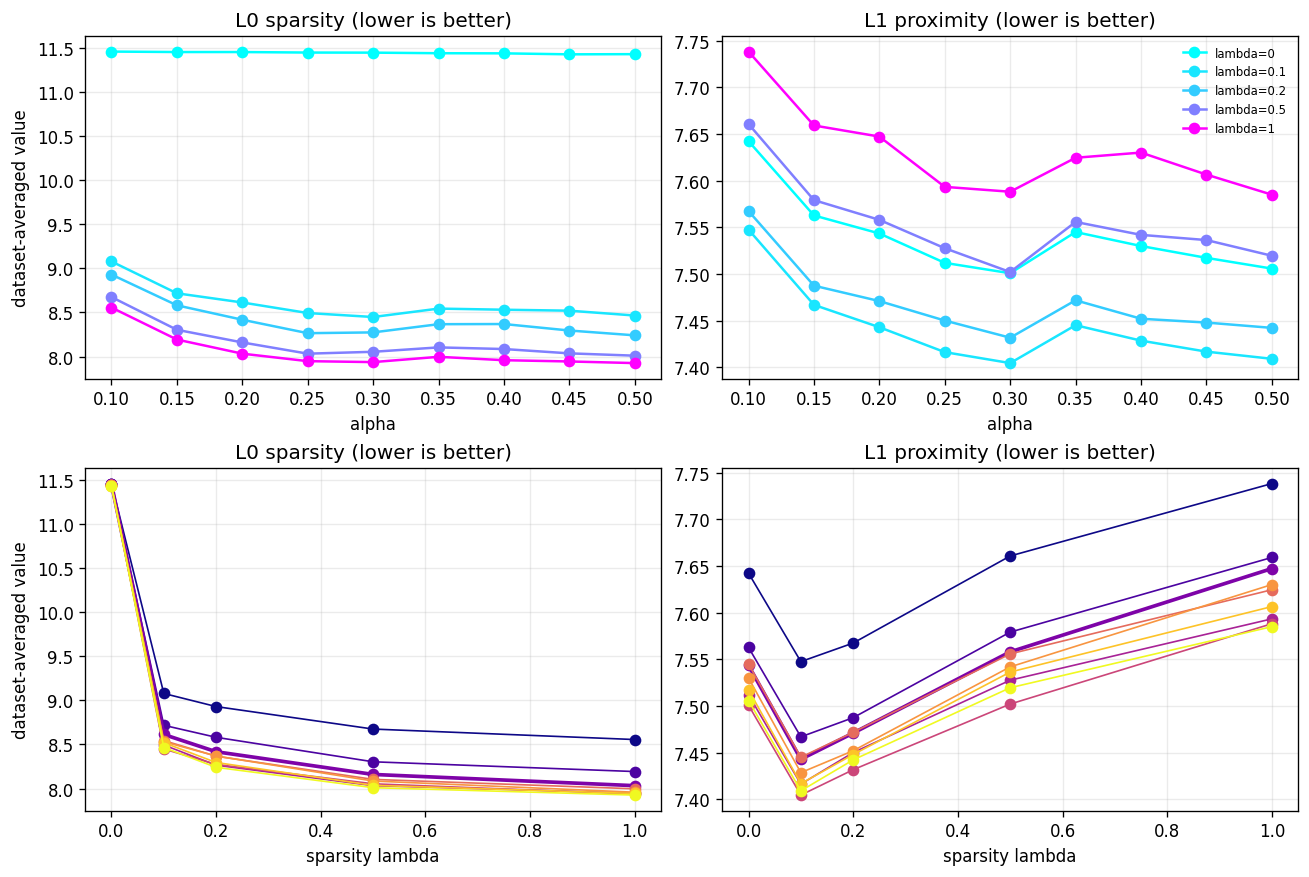

In [8]:
def plot_alpha_lambda_ablations(summary_df: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.2), constrained_layout=True)
    lambda_values = sorted(summary_df['sparsity_lambda'].dropna().unique())
    alpha_values = sorted(summary_df['alpha'].dropna().unique())

    lambda_cmap = plt.get_cmap('cool')
    alpha_cmap = plt.get_cmap('plasma')
    lambda_norm = plt.Normalize(min(lambda_values), max(lambda_values))
    alpha_norm = plt.Normalize(min(alpha_values), max(alpha_values))

    for lam in lambda_values:
        part = summary_df[np.isclose(summary_df['sparsity_lambda'], lam)].sort_values('alpha')
        color = lambda_cmap(lambda_norm(lam))
        axes[0, 0].plot(part['alpha'], part['l0_mean'], marker='o', color=color, label=f'{lam:g}')
        axes[0, 1].plot(part['alpha'], part['l1_mean'], marker='o', color=color)

    for alpha in alpha_values:
        part = summary_df[np.isclose(summary_df['alpha'], alpha)].sort_values('sparsity_lambda')
        color = alpha_cmap(alpha_norm(alpha))
        lw = 2.2 if np.isclose(alpha, SELECTED_ALPHA) else 1.0
        axes[1, 0].plot(part['sparsity_lambda'], part['l0_mean'], marker='o', color=color, linewidth=lw)
        axes[1, 1].plot(part['sparsity_lambda'], part['l1_mean'], marker='o', color=color, linewidth=lw)

    for ax in axes[:, 0]:
        ax.set_ylabel('dataset-averaged value')
        ax.set_title('L0 sparsity (lower is better)')
    for ax in axes[:, 1]:
        ax.set_title('L1 proximity (lower is better)')
    for ax in axes[0, :]:
        ax.set_xlabel('alpha')
    for ax in axes[1, :]:
        ax.set_xlabel('sparsity lambda')

    axes[0, 1].legend(handles=axes[0, 0].lines, labels=[f'lambda={v:g}' for v in lambda_values], fontsize=7, frameon=False, loc='best')
    return fig, axes

plot_alpha_lambda_ablations(CERTCF_ABLATION_DF);


## LiRPA Backend Ablation

The tables below are the HELOC diagnostics reported in the appendix. Set `RECOMPUTE_LIRPA=True` only when you want to repeat the expensive backend comparison.


In [9]:
LIRPA_BACKEND_VOLUME_DF = pd.DataFrame([
    ('CROWN', 10.41, '---', 0.971, 1.000, -39.81),
    ('Optimized CROWN', 151.09, '+1352%', 0.985, 1.000, -39.78),
    ('alpha-CROWN', 147.39, '+1316%', 0.985, 1.000, -39.78),
], columns=['backend', 'build_s', 'overhead', 'retained_mean', 'retained_median', 'median_log_volume'])

LIRPA_BACKEND_CF_DF = pd.DataFrame([
    ('CROWN', 100.0, 3.65, 11.64, 16.32, 0.0134),
    ('Optimized CROWN', 100.0, 3.66, 11.68, 16.38, 0.0132),
    ('alpha-CROWN', 100.0, 3.66, 11.68, 16.38, 0.0137),
], columns=['backend', 'validity_pct', 'l2', 'l1', 'l0', 'query_s'])

if RECOMPUTE_LIRPA:
    raise NotImplementedError(
        'The full LiRPA backend recomputation is preserved in notebooks/archive/6.39 - CertCF LiRPA backend ablation HELOC.ipynb.'
    )

print('Certified-region diagnostics')
display(LIRPA_BACKEND_VOLUME_DF)
print('Counterfactual quality and query cost')
display(LIRPA_BACKEND_CF_DF)


Certified-region diagnostics


,backend,build_s,overhead,retained_mean,retained_median,median_log_volume
0,CROWN,10.41,---,0.971,1.0,-39.81
1,Optimized CROWN,151.09,+1352%,0.985,1.0,-39.78
2,alpha-CROWN,147.39,+1316%,0.985,1.0,-39.78


Counterfactual quality and query cost


,backend,validity_pct,l2,l1,l0,query_s
0,CROWN,100.0,3.65,11.64,16.32,0.0134
1,Optimized CROWN,100.0,3.66,11.68,16.38,0.0132
2,alpha-CROWN,100.0,3.66,11.68,16.38,0.0137


## Optional Export

Exports are disabled by default so the notebook does not write artifacts during normal execution.


In [10]:
if EXPORT_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    HYPERPARAMETER_DF.to_csv(OUTPUT_DIR / 'appendix_hyperparameters.csv', index=False)
    FACE_EPSILON_DF.to_csv(OUTPUT_DIR / 'appendix_face_epsilon.csv', index=False)
    ROBUSTNESS_HEATMAP_DF.to_csv(OUTPUT_DIR / 'appendix_robustness_heatmap.csv', index=False)
    BUILD_TIME_DF.to_csv(OUTPUT_DIR / 'appendix_build_time.csv', index=False)
    QUERY_TIME_DF.to_csv(OUTPUT_DIR / 'appendix_query_time.csv', index=False)
    CERTCF_ABLATION_DF.to_csv(OUTPUT_DIR / 'appendix_certcf_alpha_lambda_ablation.csv', index=False)
    LIRPA_BACKEND_VOLUME_DF.to_csv(OUTPUT_DIR / 'appendix_lirpa_backend_volume.csv', index=False)
    LIRPA_BACKEND_CF_DF.to_csv(OUTPUT_DIR / 'appendix_lirpa_backend_cf.csv', index=False)
    print(f'Wrote appendix artifacts to {OUTPUT_DIR}')
else:
    print('EXPORT_OUTPUTS=False; no files written.')


EXPORT_OUTPUTS=False; no files written.
